In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

UNI_LIST = ['Bridgewater', 'Fitchburg', 'Framingham', 'MCLA', 'Salem', 'UMass Amherst', 'UMass Boston', 'UMass Lowell', 'UMass Dartmouth', 'Westfield', 'Worcester']
#Sorry for hard coding these :(
COMP = [0.30, 0.58, 0.05, 0.11, 0.20, 0.25, 0.09, 0.22, 0.29, 0.11, 0.18]
MATH = [0.65, 0.97, 0.13, 0.40, 0.83, 0.98, 0.47, 0.52, 0.52, 0.53, 0.63]
SCI  = [1.00, 1.00, 1.00, 0.93, 1.00, 1.00, 1.00, 0.53, 0.78, 0.97, 1.00]
HUM  = [np.nan, np.nan, np.nan, 0.67, np.nan, np.nan, np.nan, 1.00, 1.00, 0.67, 0.47]
df = pd.DataFrame({'University':UNI_LIST, 'Computing':COMP, 'Math':MATH, 'Science':SCI, 'Non-STEM':HUM})
df[['Computing', 'Math', 'Science', 'Non-STEM']].mean()

Computing    0.216364
Math         0.602727
Science      0.928182
Non-STEM     0.762000
dtype: float64

/var/folders/5_/wyyt684n44q4_557k6crj7180000gn/T/ipykernel_3520/7534548.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.swarmplot(data=long, x='Course Type', y='Percent of Transferable Requirements', ax=ax,
/opt/anaconda3/lib/python3.13/site-packages/seaborn/categorical.py:3399: UserWarning: 9.1% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


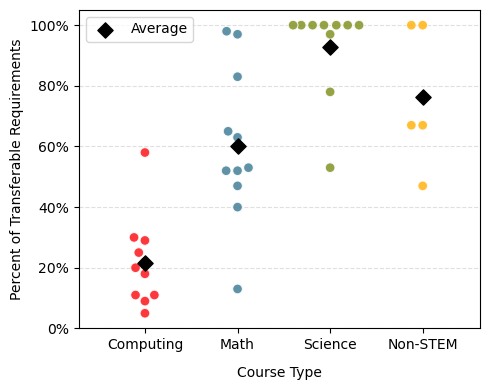

In [2]:
from matplotlib.ticker import PercentFormatter



long = df[['Computing', 'Math', 'Science', 'Non-STEM']].melt(var_name='Course Type', value_name='Percent of Transferable Requirements').dropna()
fig, ax = plt.subplots(figsize=(5, 4))



palette = {'Computing': '#FD151B', 'Math': '#437F97', 'Science': '#849324', 'Non-STEM': '#FFB30F'}
cats = ['Computing', 'Math', 'Science', 'Non-STEM']

sns.swarmplot(data=long, x='Course Type', y='Percent of Transferable Requirements', ax=ax,
              palette=palette, order=cats,
              size=7, alpha=0.85, edgecolor='white', linewidth=0.8)

means = long.groupby('Course Type')['Percent of Transferable Requirements'].mean().reindex(cats)
ax.scatter(range(len(means)), means.values, marker='D',
           color='black', s=60, zorder=5, label='Average')

ax.set_ylim(-0.05, 1.1)
ax.margins(x=0.2)
ax.set_xlabel('Course Type', labelpad=10)
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1))
ax.set_ylim(0, 1.05)
ax.grid(axis='y', linestyle='--', alpha=0.4)
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig('images/field_distribution.png', bbox_inches='tight', dpi=150)
plt.show()
